## Chains in LangChain

A chain connects multiple steps together so that the output of one step automatically becomes the input of the next step.

This becomes important when you move from a simple LLM call to a real LLM application.

Your notes start with this simple flow:

User Input -> Prompt -> LLM -> Output

In [ ]:
# User:
# "Explain attention mechanism"

#         ↓

# Prompt
# "You are an ML teacher.
# Explain the following topic:
# {user_question}"

#         ↓

#         LLM

#         ↓

# "Attention is a mechanism..."


# In Python, you might manually do:

prompt = template.invoke({
    "user_question": user_input
})

result = model.invoke(prompt)

print(result.content)

There are multiple operations happening here:

1. Create/fill the prompt.
2. Send prompt to LLM.
3. Receive LLM response.
4. Extract/process the response.
5. Show the result.

Your notes are saying that when applications become more complicated, manually performing every step becomes inconvenient.

That's where chains come in.

## Why chains ?

In [ ]:
# Why do we need Chains?

# Imagine you're building a research assistant.
# You want:
# User question
#       ↓
# Generate research answer
#       ↓
# Summarize answer
#       ↓
# Translate summary
#       ↓
# Convert result into JSON
#       ↓
# Store JSON in database

# Without a chain, you might write:

# prompt1 = template1.invoke(user_input)

# response1 = model.invoke(prompt1)

# prompt2 = template2.invoke(response1.content)

# response2 = model.invoke(prompt2)

# prompt3 = template3.invoke(response2.content)

# response3 = model.invoke(prompt3)

# parsed = parser.invoke(response3)

A chain allows you to represent this as a pipeline. Connect components and let data flow automatically between them.

You can create linear, parallel and conditional chains 

## Simple Chain

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv


template=PromptTemplate(
    template="Generate 5 interesting facts about {topic}",
    input_variables=['topic']
)

model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
parser=StrOutputParser()
chain = template | model | parser
result=chain.invoke({'topic':'Pokemon'})
print(result)

Here are 5 interesting facts about Pokémon:

### 1. Rhydon Was the First Pokémon Ever Designed
Even though Bulbasaur is #001 in the Pokédex and Arceus is considered the "god" of Pokémon in the lore, **Rhydon** was the very first Pokémon ever created by Game Freak. Ken Sugimori, the lead designer, confirmed that Rhydon’s early index number in the original game code (Index 001) reflects its status as the original design template. This is also why statues of Rhydon appear frequently in the early games' Pokémon Gyms.

### 2. Clefairy Was Almost the Mascot Instead of Pikachu
Before Pikachu became the global icon of the franchise, **Clefairy** was chosen to be the main mascot. The creators initially thought Clefairy’s pink, cute design would appeal to a broad audience and make the franchise more approachable. However, they switched to Pikachu right before the anime launched because yellow was a distinct, easily recognizable color for children, and Pikachu appealed equally to both boys and gi

## | (Pipe operator):


Passes the output of the component on the left into the component on the right.

chain = prompt | model means Prompt → Model

## To visualize the Chain

In [6]:
chain.get_graph().print_ascii()

      +-------------+      
      | PromptInput |      
      +-------------+      
             *             
             *             
             *             
    +----------------+     
    | PromptTemplate |     
    +----------------+     
             *             
             *             
             *             
+------------------------+ 
| ChatGoogleGenerativeAI | 
+------------------------+ 
             *             
             *             
             *             
    +-----------------+    
    | StrOutputParser |    
    +-----------------+    
             *             
             *             
             *             
+-----------------------+  
| StrOutputParserOutput |  
+-----------------------+  


## Sequential Chain

Topic -> LLM -> Detailed Report -> LLM -> Summarize 5 imp points 

Calling LLM 2 times

In [1]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace

load_dotenv()

True

In [7]:
llm= HuggingFaceEndpoint(
    repo_id='Qwen/Qwen3-4B-Instruct-2507',
    task='text-generation'
)
model=ChatHuggingFace(llm=llm)
parser=StrOutputParser()

template1=PromptTemplate(
    template="Generate a detailed report on the {topic}",
    input_variables=['topic']
)

template2=PromptTemplate(
    template="Generate a 5 pointer summary from the following {text}",
        input_variables=['text']
)


chain= template1 | model | parser | template2 | model | parser


result=chain.invoke({'topic':'Anime'})

print(result)

**5-Point Summary: Anime as a Cultural and Artistic Phenomenon**

1. **Rich Historical Evolution** – Anime traces its origins to early 20th-century Japanese animation, with key milestones including *The Shogun’s Daughter* (1917), the post-war revival through Toei and Toho, and the cultural breakthrough of *Astro Boy* (1963), which established anime as a major form of entertainment.

2. **Global Cultural Influence** – Anime has transcended Japan to become a worldwide phenomenon, shaping global pop culture in fashion, music, gaming, and literature, and fostering international fan communities and cross-cultural exchanges.

3. **Diverse Themes and Artistic Innovation** – From philosophical sci-fi in *Mobile Suit Gundam* to groundbreaking visual storytelling in *Akira*, anime explores complex themes such as identity, war, technology, and human emotion, showcasing narrative depth and artistic excellence.

4. **Significant Economic and Industry Impact** – The anime industry drives substantial

In [8]:
chain.get_graph().print_ascii()

     +-------------+       
     | PromptInput |       
     +-------------+       
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *              
   +-----------------+     
   | ChatHuggingFace |     
   +-----------------+     
            *              
            *              
            *              
   +-----------------+     
   | StrOutputParser |     
   +-----------------+     
            *              
            *              
            *              
+-----------------------+  
| StrOutputParserOutput |  
+-----------------------+  
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *       

## Parallel Chain

User will give detailed text on a topic to LLM (ex-Linear Regression)

We want to generate notes from the doc and We want to generate quiz from that doc and we will combine both and show it to user


In [9]:

# doc -> LLM -> Notes---|
#                       | Combining both 
# doc -> LLM -> Quiz ---| 

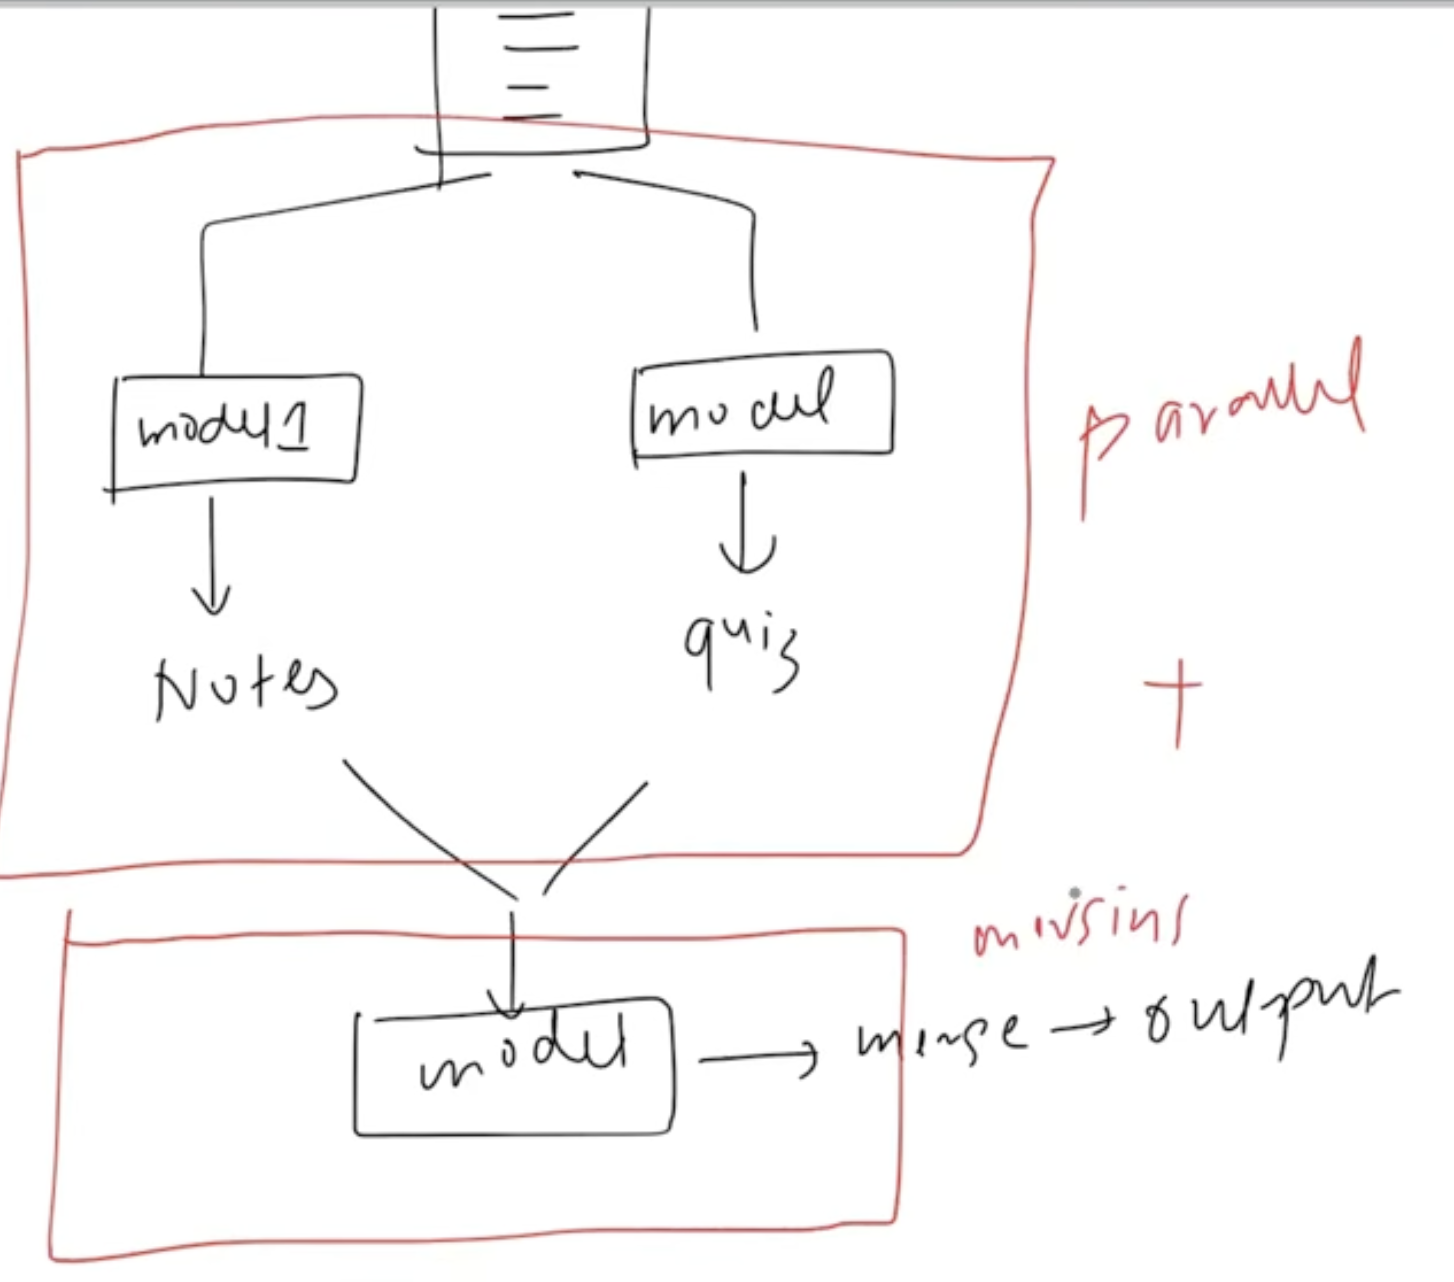

In [25]:
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

True

In [28]:
import os
llm1 = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b:fastest",
    task='text-generation'
)

llm2= HuggingFaceEndpoint(
    repo_id='deepseek-ai/DeepSeek-R1:fastest',
    task='text-generation'
)

model1=ChatHuggingFace(llm=llm1)

model2=ChatHuggingFace(llm=llm2)

parser=StrOutputParser()

prompt1=PromptTemplate(
    template='Generate short and simple notes from the following \n {text}',
    input_variables=['text']
)

prompt2=PromptTemplate(
    template='Generate 5 short questions and answers from the following \n {text}',
    input_variables=['text']
)

prompt3=PromptTemplate(
    template='Merge the provided notes and quiz into a single document. Just combine them. \n notes->{notes} and quiz ->{quiz}',
    input_variables=['notes','quiz']
)


In [29]:
## Parallel chain: to make parallel chain we need runnable parallel
from langchain_core.runnables import RunnableParallel
# RunnableParallel is kind of runnable, with its help we can execute parallel chain

## you provide a dict {'name of chain1': chain1, 'name of chain2':chain2 }

chain1= prompt1 | model1 | parser
chain2= prompt2 | model2 | parser

parallel_chain=RunnableParallel(
    {
        'notes': chain1,
        'quiz':chain2
    }
)

merged_chain = prompt3 | model1 | parser


final_chain = parallel_chain | merged_chain 

text='''
Anime (Japanese: アニメ; IPA: [aꜜɲime] ⓘ;[a] derived from a shortening of the English word animation) is animation originating from Japan. Outside Japan and in English, anime refers specifically to animation produced in Japan.[1] However, anime, in Japan and in Japanese, describes all animated works, regardless of style or origin. Many works of animation with a similar style to Japanese animation are also produced outside Japan. Video games sometimes also feature themes and art styles that may be labelled as anime.

The earliest commercial Japanese animation dates to 1917. A characteristic art style emerged in the 1960s with the works of cartoonist Osamu Tezuka and spread in the following decades, developing a large domestic audience. Anime is distributed theatrically, through television broadcasts, directly to home media, and over the Internet. In addition to original works, anime are often adaptations of Japanese comics (manga), light novels, or video games. It is classified into numerous genres targeting various broad and niche audiences.[2]

Anime is a diverse medium with distinctive production methods that have adapted in response to emergent technologies. Historically and predominantly hand-drawn, anime combines graphic art, characterization, cinematography, and other forms of imaginative and individualistic techniques.[3] Compared to Western animation, anime production generally focuses less on movement and more on the detail of settings and use of "camera effects", such as panning, zooming, and angle shots.[3] Diverse art styles are used, and character proportions and features can be quite varied, with a common characteristic feature being large and emotive eyes.[4]

The anime industry consists of over 430 production companies, including major studios such as Studio Ghibli, Kyoto Animation, Sunrise, Bones, Ufotable, MAPPA, Wit Studio, CoMix Wave Films, Madhouse, Inc., TMS Entertainment, Studio Pierrot, Production I.G, Nippon Animation and Toei Animation. Since the 1980s, the medium has also seen widespread international success with the rise of foreign dubbed and subtitled programming, and since the 2010s due to the rise of streaming services and a widening demographic embrace of anime culture, both within Japan and worldwide.[5][6] As of 2016, Japanese animation accounted for 60% of the world's animated television shows.[7] By 2022, anime had become one of the fastest-growing genres of content globally.[8] The medium is currently characterised by increased globalization, expansive cross-cultural collaboration, and significant brand integration, as Japanese-produced animation continues to influence and shape media and popular culture on a global scale.[
'''
result=final_chain.invoke({'text':text})

print(result)

**Anime – Quick Facts**

- **What it is**  
  - Japanese‑originated animation.  
  - In English “anime” = animation made in Japan.  
  - In Japan “anime” = any animated work, no matter where it’s from.

- **History**  
  - First commercial Japanese cartoons appeared in **1917**.  
  - Modern style shaped in the **1960s** by **Osamu Tezuka**.  
  - Grew a big domestic audience and later worldwide fans.

- **How it’s shown**  
  - Theatrical releases  
  - TV broadcasts  
  - Home video (DVD/Blu‑ray)  
  - Online streaming  

- **Typical sources**  
  - Original stories  
  - Adaptations of **manga**, light novels, or video games  

- **Style & Production**  
  - Mostly hand‑drawn (still the main method).  
  - Focus on detailed backgrounds, camera tricks (panning, zoom, angles) more than fluid movement.  
  - Wide range of art styles; a common trait is **large, expressive eyes**.

- **Industry**  
  - > 430 production companies.  
  - Famous studios: **Studio Ghibli, Kyoto Animation, Su

In [ ]:
## Problem: It just combined them in its own... We need to give it a proper logic
## We use RunnableLambda to give the exact combine logic
from langchain_core.runnables import RunnableLambda
import os
llm1 = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b:fastest",
    task='text-generation'
)

llm2= HuggingFaceEndpoint(
    repo_id='deepseek-ai/DeepSeek-R1:fastest',
    task='text-generation'
)

model1=ChatHuggingFace(llm=llm1)

model2=ChatHuggingFace(llm=llm2)

parser=StrOutputParser()

prompt1=PromptTemplate(
    template='Generate short and simple notes from the following \n {text}',
    input_variables=['text']
)

prompt2=PromptTemplate(
    template='Generate 5 short questions and answers from the following \n {text}',
    input_variables=['text']
)


def merge_results(result):
    return f""" 
===== NOTES =====

{result['notes']}

===== QUIZ =====

{result['quiz']}

"""
chain1= prompt1 | model1 | parser
chain2= prompt2 | model2 | parser

parallel_chain=RunnableParallel(
    {
        'notes': chain1,
        'quiz':chain2
    }
)
final_chain = parallel_chain | RunnableLambda(merge_results)
text='''
Anime (Japanese: アニメ; IPA: [aꜜɲime] ⓘ;[a] derived from a shortening of the English word animation) is animation originating from Japan. Outside Japan and in English, anime refers specifically to animation produced in Japan.[1] However, anime, in Japan and in Japanese, describes all animated works, regardless of style or origin. Many works of animation with a similar style to Japanese animation are also produced outside Japan. Video games sometimes also feature themes and art styles that may be labelled as anime.

The earliest commercial Japanese animation dates to 1917. A characteristic art style emerged in the 1960s with the works of cartoonist Osamu Tezuka and spread in the following decades, developing a large domestic audience. Anime is distributed theatrically, through television broadcasts, directly to home media, and over the Internet. In addition to original works, anime are often adaptations of Japanese comics (manga), light novels, or video games. It is classified into numerous genres targeting various broad and niche audiences.[2]

Anime is a diverse medium with distinctive production methods that have adapted in response to emergent technologies. Historically and predominantly hand-drawn, anime combines graphic art, characterization, cinematography, and other forms of imaginative and individualistic techniques.[3] Compared to Western animation, anime production generally focuses less on movement and more on the detail of settings and use of "camera effects", such as panning, zooming, and angle shots.[3] Diverse art styles are used, and character proportions and features can be quite varied, with a common characteristic feature being large and emotive eyes.[4]

The anime industry consists of over 430 production companies, including major studios such as Studio Ghibli, Kyoto Animation, Sunrise, Bones, Ufotable, MAPPA, Wit Studio, CoMix Wave Films, Madhouse, Inc., TMS Entertainment, Studio Pierrot, Production I.G, Nippon Animation and Toei Animation. Since the 1980s, the medium has also seen widespread international success with the rise of foreign dubbed and subtitled programming, and since the 2010s due to the rise of streaming services and a widening demographic embrace of anime culture, both within Japan and worldwide.[5][6] As of 2016, Japanese animation accounted for 60% of the world's animated television shows.[7] By 2022, anime had become one of the fastest-growing genres of content globally.[8] The medium is currently characterised by increased globalization, expansive cross-cultural collaboration, and significant brand integration, as Japanese-produced animation continues to influence and shape media and popular culture on a global scale.[
'''

result=final_chain.invoke({'text':text})
print(result)

 
===== NOTES =====

**Anime – Quick Facts**

- **Definition**
  - Japanese word for “animation”; in English, it usually means animation made in Japan.
  - In Japan, “anime” covers any animated work, no matter where it’s from.

- **History**
  - First commercial Japanese animation: 1917.
  - Distinctive style created in the 1960s by Osamu Tezuka.
  - Grew into a large domestic audience and later worldwide popularity.

- **How It’s Distributed**
  - Theaters, TV broadcast, home video, and online streaming.
  - Often adapted from manga, light novels, or video games.

- **Style & Production**
  - Historically hand‑drawn; now mixes traditional and digital techniques.
  - Emphasizes detailed settings, camera effects (panning, zoom, angles) over fluid movement.
  - Common visual hallmark: large, expressive eyes; many art‑style variations.

- **Industry**
  - > 430 production companies.
  - Major studios: Studio Ghibli, Kyoto Animation, Sunrise, Bones, Ufotable, MAPPA, Wit Studio, Madhouse, T

In [31]:
final_chain.get_graph().print_ascii()

             +---------------------------+               
             | Parallel<notes,quiz>Input |               
             +---------------------------+               
                 ***               ***                   
              ***                     ***                
            **                           **              
+----------------+                  +----------------+   
| PromptTemplate |                  | PromptTemplate |   
+----------------+                  +----------------+   
          *                                   *          
          *                                   *          
          *                                   *          
+-----------------+                 +-----------------+  
| ChatHuggingFace |                 | ChatHuggingFace |  
+-----------------+                 +-----------------+  
          *                                   *          
          *                                   *          
          *   

## Conditional Chain

User will give feedback about a product (eg we work for amazon), We have to understand the sentiment whether it is positive or negative. If it is positive, we will reply like thank you for your kind words

If sentiment is negative write something like we are sorry for inconvinence.

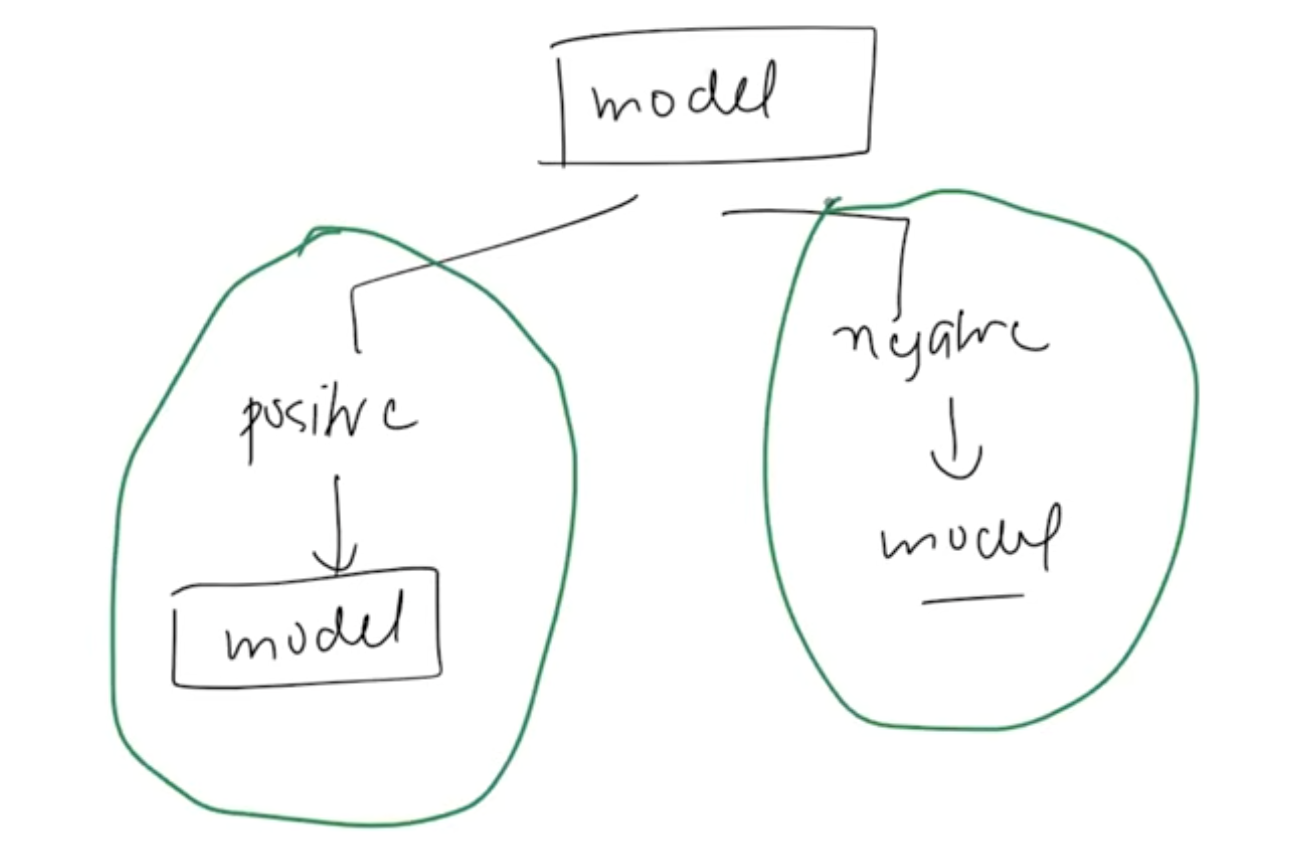

Only 1 path will get executed not both 

In [32]:
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

True

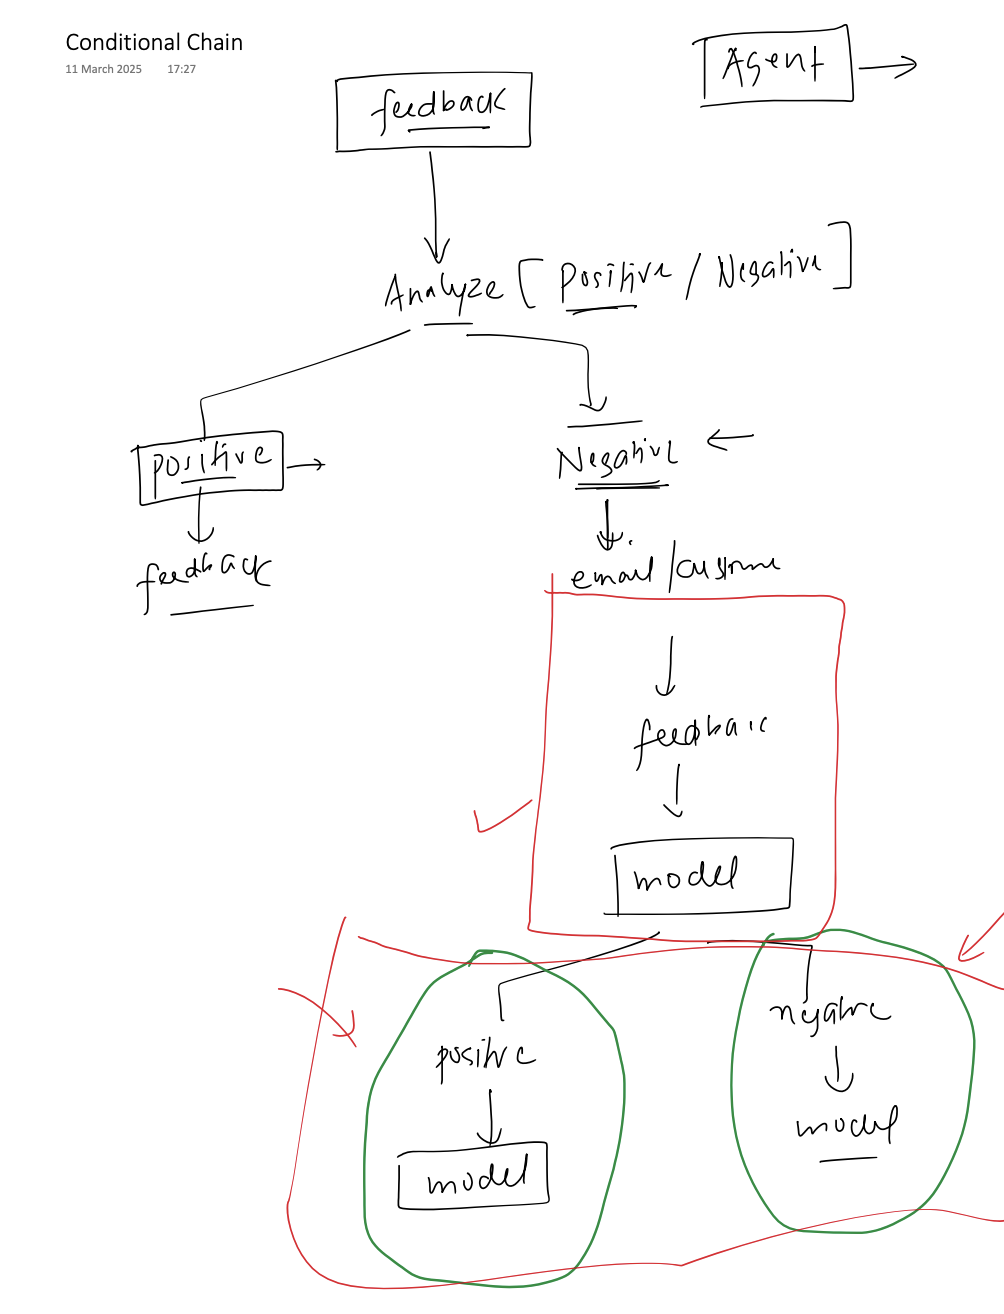

In [33]:
llm= HuggingFaceEndpoint(
    repo_id='Qwen/Qwen3-4B-Instruct-2507',
    task='text-generation'
)
model=ChatHuggingFace(llm=llm)
parser=StrOutputParser()


prompt1= PromptTemplate(
    template='Classify the sentiment of the following feedback text into positive or negative \n {feedback}',
    input_variables=['feedback']
)


classifier=prompt1 | model | parser

result=classifier.invoke({'feedback':'This is a terrible smartphone'})
print(result)

The sentiment of the feedback text "This is a terrible smartphone" is **negative**.


I want either positive or negative not this whole sentence Therefore we use pydantic Objects

In [35]:
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel,Field
from typing import Literal

class Feedback(BaseModel):
    sentiment:Literal['positive','negative']=Field(description='Give the sentiment of the feedback')

parser2=PydanticOutputParser(pydantic_object=Feedback)

prompt1= PromptTemplate(
    template='Classify the sentiment of the following feedback text into positive or negative \n {feedback} \n {format_instruction}',
    partial_variables={'format_instruction':parser2.get_format_instructions()},
    input_variables=['feedback']
)


classifier=prompt1 | model | parser2

result=classifier.invoke({'feedback':'This is a terrible smartphone'})
print(result)



sentiment='negative'


## For implementing conditional branch we use RunnableBranch

In runnable branch you send multiple tuples: ( (condition1,chain1),(condition2,chain2) )

In [36]:
from langchain_core.runnables import RunnableBranch

prompt2 = PromptTemplate(
    template="Write an appropriate response to this positive feedback \n {feedback}",
    input_variables=['feedback']
)
prompt3 = PromptTemplate(
    template="Write an appropriate response to this negative feedback \n {feedback}",
    input_variables=['feedback']
)

chain1= prompt2 | model | parser
chain2= prompt3 | model | parser
branch_chain=RunnableBranch(
    (lambda x:x.sentiment=='positive',chain1), ## function gets x as an input and x is Feedback object
    (lambda x:x.sentiment=='negative',chain2),
    RunnableLambda(lambda x:" Could not find sentiment")## default chain when all the above conditions don't match
    ## to convert a function to a chain we use Runnable lambda 
)

## Runnable lambda: converts lambda function to runnable. if runnable can be converted to chain easily

final_chain= classifier | branch_chain

result=final_chain.invoke({'feedback':'This is a terrible phone'})
print(result)

I'm sorry to hear you're unhappy with your experience. I truly value your feedback and want to make things right. Could you please let me know what specifically didn’t meet your expectations? I’m here to listen and improve—thank you for helping me do so.


In [37]:
final_chain.get_graph().print_ascii()

    +-------------+      
    | PromptInput |      
    +-------------+      
            *            
            *            
            *            
   +----------------+    
   | PromptTemplate |    
   +----------------+    
            *            
            *            
            *            
  +-----------------+    
  | ChatHuggingFace |    
  +-----------------+    
            *            
            *            
            *            
+----------------------+ 
| PydanticOutputParser | 
+----------------------+ 
            *            
            *            
            *            
       +--------+        
       | Branch |        
       +--------+        
            *            
            *            
            *            
    +--------------+     
    | BranchOutput |     
    +--------------+     
